# EAP-IG Localization Analysis

Model-agnostic analysis notebook for the animacy circuit localization experiments. It expects outputs from `python scripts/executable/run.py eap-localization ...` under `results/eap_ig_localization/<model>/<day>/`.

In [35]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 200)


def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "results").is_dir() and (candidate / "scripts").is_dir():
            return candidate
        nested = candidate / "animacy-circuit"
        if (nested / "results").is_dir() and (nested / "scripts").is_dir():
            return nested
    raise FileNotFoundError("Could not find animacy-circuit project root")


PROJECT_ROOT = find_project_root()
RESULTS_ROOT = PROJECT_ROOT / "results" / "eap_ig_localization"


def apply_model_order(frame, model_order):
    if not frame.empty and "model_dir" in frame.columns:
        frame = frame.copy()
        frame["model_dir"] = pd.Categorical(frame["model_dir"], categories=model_order, ordered=True)
    return frame


def ensure_model_panels(frame, model_order, placeholder_values):
    frame = frame.copy()
    if "model_dir" not in frame.columns:
        frame["model_dir"] = pd.Series(dtype="object")
    frame["model_dir"] = frame["model_dir"].astype("object")
    frame["_placeholder"] = False
    present_models = set(frame["model_dir"].dropna().astype(str))
    missing_models = [model for model in model_order if model not in present_models]
    if missing_models:
        placeholder_rows = []
        base_cols = list(frame.columns)
        for model_dir in missing_models:
            row = {col: np.nan for col in base_cols}
            row.update(placeholder_values)
            row["model_dir"] = model_dir
            row["_placeholder"] = True
            placeholder_rows.append(row)
        frame = pd.concat([frame, pd.DataFrame(placeholder_rows)], ignore_index=True, sort=False)
    return apply_model_order(frame, model_order)


def style_model_facets(fig, height=760):
    fig.for_each_annotation(lambda ann: ann.update(text=ann.text.split("=")[-1]))
    fig.update_xaxes(matches=None)
    for trace in fig.data:
        trace_name = str(getattr(trace, "name", ""))
        trace_group = str(getattr(trace, "legendgroup", ""))
        if "__missing__" in trace_name or "__missing__" in trace_group:
            trace.showlegend = False
    fig.update_layout(height=height)
    return fig


def annotate_missing_model_panels(fig, plotted_frame, model_order, message):
    if plotted_frame.empty or "_placeholder" not in plotted_frame.columns:
        return fig
    missing_models = set(plotted_frame.loc[plotted_frame["_placeholder"], "model_dir"].dropna().astype(str))
    facet_titles = {
        str(ann.text).split("=")[-1]: ann
        for ann in fig.layout.annotations
        if isinstance(getattr(ann, "text", None), str)
    }
    axis_pairs = []
    axis_index = 1
    while True:
        xaxis_name = "xaxis" if axis_index == 1 else f"xaxis{axis_index}"
        yaxis_name = "yaxis" if axis_index == 1 else f"yaxis{axis_index}"
        xaxis = getattr(fig.layout, xaxis_name, None)
        yaxis = getattr(fig.layout, yaxis_name, None)
        if xaxis is None or yaxis is None or xaxis.domain is None or yaxis.domain is None:
            break
        axis_pairs.append((xaxis, yaxis))
        axis_index += 1
    for model_dir in model_order:
        if model_dir not in missing_models:
            continue
        title_ann = facet_titles.get(model_dir)
        if title_ann is None:
            continue
        panel = None
        for xaxis, yaxis in axis_pairs:
            x0, x1 = xaxis.domain
            y0, y1 = yaxis.domain
            if x0 <= title_ann.x <= x1 and y1 <= title_ann.y + 1e-9:
                if panel is None or y1 > panel[1].domain[1]:
                    panel = (xaxis, yaxis)
        if panel is None:
            continue
        xaxis, yaxis = panel
        x = sum(xaxis.domain) / 2
        y = sum(yaxis.domain) / 2
        fig.add_annotation(
            x=x,
            y=y,
            xref="paper",
            yref="paper",
            text=message,
            showarrow=False,
            font={"size": 14, "color": "crimson"},
        )
    return fig


def finalize_model_facets(fig, plotted_frame, model_order, missing_message, height=760):
    style_model_facets(fig, height=height)
    annotate_missing_model_panels(fig, plotted_frame, model_order, missing_message)
    return fig


PROJECT_ROOT


PosixPath('/gpfs/home4/spunzo/grammatical-circuits/animacy-circuit')

## Select Models

Set `MODEL_QUERIES` to a list of model slugs or substrings. Leave it as `None` to analyze the latest non-experimental run for every discovered model. When `DAY = None`, the notebook prefers runs with saved `topk_evaluations.csv` and `ranking_source.kind = localized_attribution` when available, while still using every matching run in the seed-comparison section. Plotly facets are used to keep each notebook section as a single figure with one panel per model.


In [36]:
RESULTS_ROOT


PosixPath('/gpfs/home4/spunzo/grammatical-circuits/animacy-circuit/results/eap_ig_localization')

In [37]:
MODEL_QUERIES = None
DAY = None
INCLUDE_EXPERIMENTAL = False
MODEL_FACET_WRAP = 2
PREFERRED_RANKING_SOURCE_KIND = "localized_attribution"
PREFER_RUNS_WITH_TOPK = True

EXPERIMENTAL_DAY_TOKENS = (
    "smoke",
    "debug",
    "test",
    "pilot",
    "tmp",
)
MERGE_DAY_SUFFIXES = (
    "_probe",
)

def normalize(text):
    return re.sub(r"[^a-z0-9]+", "", str(text).lower())


def canonical_run_day(day_name):
    canonical = str(day_name)
    for suffix in MERGE_DAY_SUFFIXES:
        if canonical.endswith(suffix):
            return canonical[:-len(suffix)]
    return canonical


def is_experimental_run_day(day_name):
    normalized_day = normalize(day_name)
    return any(token in normalized_day for token in EXPERIMENTAL_DAY_TOKENS)


def summarize_run_dirs(run_dirs):
    ranking_source_kinds = set()
    has_topk_evaluations = False
    for run_dir in run_dirs:
        run_dir = Path(run_dir)
        has_topk_evaluations = has_topk_evaluations or (run_dir / "topk_evaluations.csv").is_file()
        for summary_path in sorted(run_dir.glob("sample_*/seed_*/localization_summary_sample_*_seed_*.json")):
            summary = json.loads(summary_path.read_text())
            ranking_source = summary.get("ranking_source", {}) or {}
            ranking_source_kinds.add(ranking_source.get("kind", "localized_attribution"))
    if not ranking_source_kinds:
        ranking_source_kinds.add("localized_attribution")
    return {
        "has_topk_evaluations": has_topk_evaluations,
        "ranking_source_kinds": sorted(ranking_source_kinds),
        "preferred_ranking_source": (
            PREFERRED_RANKING_SOURCE_KIND in ranking_source_kinds
            if PREFERRED_RANKING_SOURCE_KIND is not None
            else False
        ),
    }


def merge_manifest_dicts(manifests, source_days=None, run_dirs=None):
    if not manifests:
        return {}
    merged = json.loads(json.dumps(manifests[-1]))
    top_k_values = []
    merged_runs = {}
    for manifest in manifests:
        top_k_values.extend(manifest.get("config", {}).get("top_k", []) or [])
        for run in manifest.get("runs", []):
            key = (run.get("sample_size"), run.get("seed"))
            merged_runs[key] = run
    if top_k_values:
        merged.setdefault("config", {})["top_k"] = sorted({int(value) for value in top_k_values})
    if merged_runs:
        merged["runs"] = [merged_runs[key] for key in sorted(merged_runs)]
        merged["run_count"] = len(merged["runs"])
    merged.setdefault("paths", {})
    if source_days is not None:
        merged["paths"]["merged_source_days"] = list(source_days)
    if run_dirs is not None:
        merged["paths"]["merged_run_dirs"] = [str(Path(run_dir)) for run_dir in run_dirs]
    return merged


def discover_localization_runs(results_root=RESULTS_ROOT):
    rows = []
    if not results_root.exists():
        return pd.DataFrame(rows)
    for model_dir in sorted(path for path in results_root.iterdir() if path.is_dir()):
        for day_dir in sorted(path for path in model_dir.iterdir() if path.is_dir()):
            manifests = sorted(day_dir.glob("localization_manifest_*.json"), key=lambda p: p.stat().st_mtime)
            rows.append({
                "model_dir": model_dir.name,
                "day": day_dir.name,
                "run_dir": day_dir,
                "manifest": manifests[-1] if manifests else None,
                "experimental": is_experimental_run_day(day_dir.name),
                "modified": day_dir.stat().st_mtime,
            })
    if not rows:
        return pd.DataFrame(rows)
    raw_runs = pd.DataFrame(rows)
    raw_runs["canonical_day"] = raw_runs["day"].map(canonical_run_day)
    merged_rows = []
    for (_, canonical_day), group in raw_runs.sort_values("modified").groupby(["model_dir", "canonical_day"], sort=False):
        group = group.sort_values("modified")
        run_dirs = list(group["run_dir"])
        manifests = [manifest for manifest in group["manifest"] if manifest is not None]
        latest_row = group.iloc[-1]
        run_metadata = summarize_run_dirs(run_dirs)
        merged_rows.append({
            "model_dir": latest_row["model_dir"],
            "day": canonical_day,
            "run_dir": latest_row["run_dir"],
            "run_dirs": run_dirs,
            "manifest": manifests[-1] if manifests else None,
            "manifests": manifests,
            "source_days": list(group["day"]),
            "source_count": len(run_dirs),
            "experimental": bool(group["experimental"].any()),
            "modified": group["modified"].max(),
            **run_metadata,
        })
    return pd.DataFrame(merged_rows).sort_values(["model_dir", "modified"], ascending=[True, False]).reset_index(drop=True)


def filter_model_runs(runs, model_query, day=None, include_experimental=False):
    query = normalize(model_query)
    matches = runs[runs["model_dir"].map(lambda value: query in normalize(value))].copy()
    if day is not None:
        matches = matches[matches["day"] == day]
    elif not include_experimental:
        matches = matches[~matches["experimental"]].copy()
    if day is None and not matches.empty:
        if PREFER_RUNS_WITH_TOPK and matches["has_topk_evaluations"].any():
            matches = matches[matches["has_topk_evaluations"]].copy()
        if PREFERRED_RANKING_SOURCE_KIND is not None and matches["preferred_ranking_source"].any():
            matches = matches[matches["preferred_ranking_source"]].copy()
    if matches.empty:
        experimental_matches = runs[
            runs["model_dir"].map(lambda value: query in normalize(value))
            & runs["experimental"]
        ]["day"].tolist()
        if experimental_matches and day is None and not include_experimental:
            raise FileNotFoundError(
                "Only experimental runs matched the current filter. "
                f"Set DAY explicitly or set INCLUDE_EXPERIMENTAL=True. Matches for {model_query!r}: {experimental_matches}"
            )
        raise FileNotFoundError(f"No localization run matched model query {model_query!r}, DAY={day!r}")
    return matches.sort_values(["preferred_ranking_source", "has_topk_evaluations", "modified"], ascending=[False, False, False]).reset_index(drop=True)


runs = discover_localization_runs()
display(runs)

if runs.empty:
    raise FileNotFoundError(f"No localization runs found under {RESULTS_ROOT}")

available_models = runs["model_dir"].drop_duplicates().tolist()
requested_models = MODEL_QUERIES or available_models
matching_frames = []
selected_rows = []
for model_query in requested_models:
    model_matches = filter_model_runs(runs, model_query, day=DAY, include_experimental=INCLUDE_EXPERIMENTAL)
    matching_frames.append(model_matches)
    selected_rows.append(model_matches.iloc[0].to_dict())

matching_runs = pd.concat(matching_frames, ignore_index=True).drop_duplicates(subset=["model_dir", "day"]).reset_index(drop=True)
selected_runs = pd.DataFrame(selected_rows).drop_duplicates(subset=["model_dir"]).reset_index(drop=True)
MODEL_ORDER = selected_runs["model_dir"].tolist()
MANIFEST_BY_MODEL = {
    row["model_dir"]: merge_manifest_dicts(
        [json.loads(Path(manifest_path).read_text()) for manifest_path in row["manifests"]],
        source_days=row["source_days"],
        run_dirs=[Path(run_dir) for run_dir in row["run_dirs"]],
    )
    for _, row in selected_runs.iterrows()
}

selection_preview = selected_runs[["model_dir", "day", "source_days", "source_count", "experimental", "has_topk_evaluations", "ranking_source_kinds"]].copy()
display(Markdown("### Selected runs"))
display(selection_preview)


,model_dir,day,run_dir,run_dirs,manifest,manifests,source_days,source_count,experimental,modified,has_topk_evaluations,ranking_source_kinds,preferred_ranking_source
0,Qwen_Qwen3-4B,named_entity_truncated_localization_2026-06-16,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,[named_entity_truncated_localization_2026-06-16],1,False,1.781950e+09,True,[imported_edge_rankings],False
1,Qwen_Qwen3-4B,qwen_seed_stability,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,"[qwen_seed_stability, qwen_seed_stability_probe]",2,False,1.780863e+09,True,"[imported_edge_rankings, localized_attribution]",True
2,google_gemma-3-4b-pt,named_entity_truncated_localization_2026-06-16,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,None,[],[named_entity_truncated_localization_2026-06-16],1,False,1.781935e+09,False,[localized_attribution],True
3,google_gemma-3-4b-pt,gemma_seed_stability,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,"[gemma_seed_stability, gemma_seed_stability_pr...",2,False,1.780890e+09,True,"[imported_edge_rankings, localized_attribution]",True
4,gpt2,named_entity_truncated_localization_2026-06-16,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,[named_entity_truncated_localization_2026-06-16],1,False,1.781936e+09,True,[imported_edge_rankings],False
5,gpt2,gpt2_seed_stability,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,"[gpt2_seed_stability, gpt2_seed_stability_probe]",2,False,1.780389e+09,True,"[imported_edge_rankings, localized_attribution]",True
6,gpt2,import_smoke_2026_05_31,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,[import_smoke_2026_05_31],1,True,1.780217e+09,True,[imported_edge_rankings],False
7,meta-llama_Llama-3.2-3B,named_entity_truncated_localization_2026-06-16,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,[named_entity_truncated_localization_2026-06-16],1,False,1.781939e+09,True,[imported_edge_rankings],False
8,meta-llama_Llama-3.2-3B,llama_seed_stability,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,/gpfs/home4/spunzo/grammatical-circuits/animac...,[/gpfs/home4/spunzo/grammatical-circuits/anima...,"[llama_seed_stability, llama_seed_stability_pr...",2,False,1.780884e+09,True,"[imported_edge_rankings, localized_attribution]",True


### Selected runs

,model_dir,day,source_days,source_count,experimental,has_topk_evaluations,ranking_source_kinds
0,Qwen_Qwen3-4B,qwen_seed_stability,"[qwen_seed_stability, qwen_seed_stability_probe]",2,False,True,"[imported_edge_rankings, localized_attribution]"
1,google_gemma-3-4b-pt,gemma_seed_stability,"[gemma_seed_stability, gemma_seed_stability_pr...",2,False,True,"[imported_edge_rankings, localized_attribution]"
2,gpt2,gpt2_seed_stability,"[gpt2_seed_stability, gpt2_seed_stability_probe]",2,False,True,"[imported_edge_rankings, localized_attribution]"
3,meta-llama_Llama-3.2-3B,llama_seed_stability,"[llama_seed_stability, llama_seed_stability_pr...",2,False,True,"[imported_edge_rankings, localized_attribution]"


In [38]:
def read_csv_if_exists(path):
    path = Path(path)
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def load_merged_csv(run_rows, filename, dedupe_subset=None):
    per_model_frames = []
    for _, candidate in run_rows.iterrows():
        frames = []
        run_dirs = [Path(run_dir) for run_dir in candidate["run_dirs"]]
        source_days = list(candidate["source_days"])
        for source_day, run_dir in zip(source_days, run_dirs):
            frame = read_csv_if_exists(run_dir / filename)
            if frame.empty:
                continue
            frame["source_day"] = source_day
            frames.append(frame)
        if not frames:
            continue
        merged = pd.concat(frames, ignore_index=True)
        if dedupe_subset:
            dedupe_cols = [col for col in dedupe_subset if col in merged.columns]
            if dedupe_cols:
                merged = merged.drop_duplicates(subset=dedupe_cols, keep="last").reset_index(drop=True)
        merged["model_dir"] = candidate["model_dir"]
        merged["day"] = candidate["day"]
        per_model_frames.append(merged)
    if not per_model_frames:
        return pd.DataFrame()
    return apply_model_order(pd.concat(per_model_frames, ignore_index=True), MODEL_ORDER)


def summarize_model_outputs(run_rows):
    rows = []
    for _, candidate in run_rows.iterrows():
        run_dirs = [Path(run_dir) for run_dir in candidate["run_dirs"]]
        rows.append({
            "model_dir": candidate["model_dir"],
            "day": candidate["day"],
            "topk_evaluations_csv": any((run_dir / "topk_evaluations.csv").is_file() for run_dir in run_dirs),
            "concentration_summary_csv": any((run_dir / "concentration_summary.csv").is_file() for run_dir in run_dirs),
            "edge_stability_csv": any((run_dir / "edge_stability.csv").is_file() for run_dir in run_dirs),
            "node_stability_csv": any((run_dir / "node_stability.csv").is_file() for run_dir in run_dirs),
            "per_seed_summary_count": sum(len(list(run_dir.glob("sample_*/seed_*/localization_summary_sample_*_seed_*.json"))) for run_dir in run_dirs),
            "per_seed_eval_count": sum(len(list(run_dir.glob("sample_*/seed_*/topk_evaluations_sample_*_seed_*.csv"))) for run_dir in run_dirs),
            "cumulative_mass_count": sum(len(list(run_dir.glob("sample_*/seed_*/cumulative_mass_sample_*_seed_*.csv"))) for run_dir in run_dirs),
        })
    return apply_model_order(pd.DataFrame(rows), MODEL_ORDER)


eval_df = load_merged_csv(
    selected_runs,
    "topk_evaluations.csv",
    dedupe_subset=["sample_size", "seed", "mode", "baseline", "collapsed_edge_budget", "repeat", "matched_random"],
)
concentration_df = load_merged_csv(selected_runs, "concentration_summary.csv", dedupe_subset=["sample_size", "seed"])
edge_stability_df = load_merged_csv(selected_runs, "edge_stability.csv", dedupe_subset=["sample_size", "seed_a", "seed_b", "top_k"])
node_stability_df = load_merged_csv(selected_runs, "node_stability.csv", dedupe_subset=["sample_size", "seed_a", "seed_b", "top_k"])

for frame in (eval_df, concentration_df, edge_stability_df, node_stability_df):
    for col in frame.columns:
        if col not in {"mode", "baseline", "source_day", "model_dir", "day"}:
            try:
                frame[col] = pd.to_numeric(frame[col])
            except (TypeError, ValueError):
                pass

manifest_rows = []
for model_dir in MODEL_ORDER:
    manifest = MANIFEST_BY_MODEL.get(model_dir, {})
    row = pd.json_normalize(manifest.get("dataset_summary", {}))
    row["model_dir"] = model_dir
    manifest_rows.append(row)
manifest_df = apply_model_order(pd.concat(manifest_rows, ignore_index=True), MODEL_ORDER) if manifest_rows else pd.DataFrame()
output_status_df = summarize_model_outputs(selected_runs)

display(Markdown("### Output availability"))
display(output_status_df)
display(Markdown("### Manifest"))
display(manifest_df)
display(Markdown("### Evaluation rows"))
eval_preview_cols = [
    "model_dir", "day", "source_day", "sample_size", "seed", "mode", "baseline", "collapsed_edge_budget",
    "faithfulness_mean", "faithfulness_std", "accuracy_mean", "accuracy_std",
    "validation_examples", "expanded_edge_count", "induced_node_count",
]
display(eval_df[[col for col in eval_preview_cols if col in eval_df.columns]].sort_values(["model_dir", "sample_size", "seed", "collapsed_edge_budget"]).head(20))
display(Markdown("### Concentration rows"))
concentration_preview_cols = [
    "model_dir", "day", "source_day", "sample_size", "seed", "ranked_edge_count", "normalized_entropy",
    "effective_edge_count", "top_10_mass", "top_50_mass", "top_100_mass",
    "edges_for_80pct_mass", "edges_for_90pct_mass",
]
display(concentration_df[[col for col in concentration_preview_cols if col in concentration_df.columns]].sort_values(["model_dir", "sample_size", "seed"]).head(20))


### Output availability

,model_dir,day,topk_evaluations_csv,concentration_summary_csv,edge_stability_csv,node_stability_csv,per_seed_summary_count,per_seed_eval_count,cumulative_mass_count
0,Qwen_Qwen3-4B,qwen_seed_stability,True,True,True,True,6,6,6
1,google_gemma-3-4b-pt,gemma_seed_stability,True,True,True,True,6,6,6
2,gpt2,gpt2_seed_stability,True,True,True,True,6,6,6
3,meta-llama_Llama-3.2-3B,llama_seed_stability,True,True,True,True,6,6,6


### Manifest

,target_model,target_model_requested,source_filter_model,target_filtered_count,target_raw_accuracy.example_count,target_raw_accuracy.clean_success.count,target_raw_accuracy.clean_success.rate,target_raw_accuracy.corrupt_success.count,target_raw_accuracy.corrupt_success.rate,target_raw_accuracy.pair_success.count,target_raw_accuracy.pair_success.rate,target_raw_accuracy.recovery_margin.count,target_raw_accuracy.recovery_margin.rate,target_raw_accuracy.clean_metric_mean,target_raw_accuracy.corrupt_metric_mean,target_raw_accuracy.margin_mean,target_on_source_accuracy.example_count,target_on_source_accuracy.clean_success.count,target_on_source_accuracy.clean_success.rate,target_on_source_accuracy.corrupt_success.count,target_on_source_accuracy.corrupt_success.rate,target_on_source_accuracy.pair_success.count,target_on_source_accuracy.pair_success.rate,target_on_source_accuracy.recovery_margin.count,target_on_source_accuracy.recovery_margin.rate,target_on_source_accuracy.clean_metric_mean,target_on_source_accuracy.corrupt_metric_mean,target_on_source_accuracy.margin_mean,model_dir
0,Qwen/Qwen3-4B,Qwen 3 4B,Qwen/Qwen3-4B,4300,4300,4300,1.0,4300,1.0,4300,1.0,4300,1.0,1.518580,-0.631604,2.150185,4300,4300,1.0,4300,1.0,4300,1.0,4300,1.0,1.518580,-0.631604,2.150185,Qwen_Qwen3-4B
1,google/gemma-3-4b-pt,Gemma 3 4B base,google/gemma-3-4b-pt,4371,4371,4371,1.0,4371,1.0,4371,1.0,4371,1.0,2.241633,-0.999736,3.241368,4371,4371,1.0,4371,1.0,4371,1.0,4371,1.0,2.241633,-0.999736,3.241368,google_gemma-3-4b-pt
2,gpt2,gpt2,gpt2,4721,4721,4721,1.0,4721,1.0,4721,1.0,4721,1.0,1.531433,-1.053938,2.585372,4721,4721,1.0,4721,1.0,4721,1.0,4721,1.0,1.531433,-1.053938,2.585372,gpt2
3,meta-llama/Llama-3.2-3B,Llama 3.2 3B,meta-llama/Llama-3.2-3B,4734,4734,4734,1.0,4734,1.0,4734,1.0,4734,1.0,1.449085,-0.864698,2.313783,4734,4734,1.0,4734,1.0,4734,1.0,4734,1.0,1.449085,-0.864698,2.313783,meta-llama_Llama-3.2-3B


### Evaluation rows

,model_dir,day,source_day,sample_size,seed,mode,baseline,collapsed_edge_budget,faithfulness_mean,faithfulness_std,accuracy_mean,accuracy_std,validation_examples,expanded_edge_count,induced_node_count
0,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability,500,0,keep_top,eap_ranked,1,2.848749e-07,0.000005,0.000000,0.000000,3800,0,-2
1,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability,500,0,ablate_top,eap_ranked,1,9.953851e-01,0.263960,0.994211,0.075868,3800,2022462,1187
2,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability,500,0,keep_random,layer_type_matched_random,1,2.848749e-07,0.000005,0.000000,0.000000,3800,0,-2
3,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability,500,0,ablate_random,layer_type_matched_random,1,9.999378e-01,0.002480,0.998947,0.032427,3800,2022462,1187
4,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability,500,0,keep_top,eap_ranked,5,2.848749e-07,0.000005,0.000000,0.000000,3800,0,-2
5,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability,500,0,ablate_top,eap_ranked,5,6.000762e-01,0.999824,0.842632,0.364148,3800,2019059,1186
6,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability,500,0,keep_random,layer_type_matched_random,5,2.848749e-07,0.000005,0.000000,0.000000,3800,0,-2
7,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability,500,0,ablate_random,layer_type_matched_random,5,9.433457e-01,0.624071,0.991053,0.094166,3800,2019059,1186
8,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability,500,0,keep_top,eap_ranked,10,2.848749e-07,0.000005,0.000000,0.000000,3800,0,-2
9,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability,500,0,ablate_top,eap_ranked,10,1.013036e-01,0.162806,0.168947,0.374705,3800,2008857,1183


### Concentration rows

,model_dir,day,source_day,sample_size,seed,ranked_edge_count,normalized_entropy,effective_edge_count,top_10_mass,top_50_mass,top_100_mass,edges_for_80pct_mass,edges_for_90pct_mass
0,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability_probe,500,0,689599,0.827782,7720.526853,0.020045,0.058609,0.081801,70167,143911
1,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability_probe,500,1,689599,0.829040,8229.989430,0.019001,0.055775,0.078811,70529,144287
2,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability_probe,500,42,689599,0.827030,7549.317655,0.020246,0.059395,0.083231,69796,143405
3,google_gemma-3-4b-pt,gemma_seed_stability,gemma_seed_stability_probe,500,0,46326,0.677612,287.346133,0.134093,0.302239,0.391140,1232,2496
4,google_gemma-3-4b-pt,gemma_seed_stability,gemma_seed_stability_probe,500,1,46326,0.677654,286.069835,0.134015,0.299649,0.389794,1223,2482
5,google_gemma-3-4b-pt,gemma_seed_stability,gemma_seed_stability_probe,500,42,46326,0.676633,284.631036,0.135773,0.303352,0.392664,1219,2460
6,gpt2,gpt2_seed_stability,gpt2_seed_stability_probe,500,0,11611,0.788802,176.485782,0.152559,0.269465,0.346364,1648,3078
7,gpt2,gpt2_seed_stability,gpt2_seed_stability_probe,500,1,11611,0.787172,172.154763,0.154453,0.272839,0.350661,1643,3068
8,gpt2,gpt2_seed_stability,gpt2_seed_stability_probe,500,42,11611,0.787107,170.863661,0.155034,0.272306,0.349467,1637,3055
9,meta-llama_Llama-3.2-3B,llama_seed_stability,llama_seed_stability_probe,500,0,238323,0.818430,1685.928204,0.043997,0.082963,0.110391,24192,46880


## Seed Comparison Across Matching Runs

This section scans every run matching the selected models (and `DAY`, if set) and compares per-seed outputs across days. It is useful when different seeds live in different run folders.


In [39]:
def load_slot_summaries(run_rows):
    slot_rows = []
    concentration_rows = []
    eval_frames = []
    for _, candidate in run_rows.iterrows():
        run_dirs = [Path(run_dir) for run_dir in candidate["run_dirs"]]
        source_days = list(candidate["source_days"])
        for source_day, run_dir in zip(source_days, run_dirs):
            for summary_path in sorted(run_dir.glob("sample_*/seed_*/localization_summary_sample_*_seed_*.json")):
                summary = json.loads(summary_path.read_text())
                slot_row = {
                    "day": candidate["day"],
                    "source_day": source_day,
                    "model_dir": candidate["model_dir"],
                    "sample_size": int(summary["sample_size"]),
                    "seed": int(summary["seed"]),
                    "run_dir": str(run_dir),
                    "ranking_source_kind": summary.get("ranking_source", {}).get("kind", "localized_attribution"),
                    "ranking_source_status": summary.get("ranking_source", {}).get("status", ""),
                }
                slot_rows.append(slot_row)
                concentration = dict(summary.get("concentration", {}))
                if concentration:
                    concentration.update(slot_row)
                    concentration_rows.append(concentration)
            for eval_path in sorted(run_dir.glob("sample_*/seed_*/topk_evaluations_sample_*_seed_*.csv")):
                frame = pd.read_csv(eval_path)
                frame["day"] = candidate["day"]
                frame["source_day"] = source_day
                frame["model_dir"] = candidate["model_dir"]
                frame["run_dir"] = str(run_dir)
                frame["seed_label"] = "seed=" + frame["seed"].astype(str)
                frame["mode_label"] = frame["mode"].replace({"keep_top": "keep", "ablate_top": "ablate"})
                eval_frames.append(frame)
    slot_df = pd.DataFrame(slot_rows)
    concentration_df = pd.DataFrame(concentration_rows)
    eval_df = pd.concat(eval_frames, ignore_index=True) if eval_frames else pd.DataFrame()
    if not slot_df.empty:
        slot_df = slot_df.drop_duplicates(subset=["model_dir", "day", "sample_size", "seed", "ranking_source_kind", "ranking_source_status"], keep="last").reset_index(drop=True)
    if not concentration_df.empty:
        concentration_df = concentration_df.drop_duplicates(subset=["model_dir", "day", "sample_size", "seed", "ranking_source_kind", "ranking_source_status"], keep="last").reset_index(drop=True)
    if not eval_df.empty:
        eval_df = eval_df.drop_duplicates(subset=["model_dir", "day", "sample_size", "seed", "mode", "baseline", "collapsed_edge_budget", "repeat", "matched_random"], keep="last").reset_index(drop=True)
    for frame in (concentration_df, eval_df):
        for col in frame.columns:
            if col not in {"mode", "mode_label", "baseline", "day", "source_day", "model_dir", "run_dir", "seed_label", "ranking_source_kind", "ranking_source_status"}:
                try:
                    frame[col] = pd.to_numeric(frame[col])
                except (TypeError, ValueError):
                    pass
    return apply_model_order(slot_df, MODEL_ORDER), apply_model_order(concentration_df, MODEL_ORDER), apply_model_order(eval_df, MODEL_ORDER)


seed_slots_df, seed_concentration_df, seed_eval_df = load_slot_summaries(matching_runs)

display(Markdown("### Available seed slots"))
if seed_slots_df.empty:
    display(Markdown("No per-seed localization summaries found for the selected model filter."))
else:
    display(seed_slots_df.sort_values(["model_dir", "sample_size", "seed", "day", "source_day"]).reset_index(drop=True))

seed_metric_cols = ["faithfulness_mean", "accuracy_mean"]
seed_metric_titles = {
    "faithfulness_mean": "Faithfulness Mean",
    "accuracy_mean": "Accuracy Mean",
}
seed_mode_specs = [
    ("ablate_top", "Comprehensiveness (ablate)"),
    ("keep_top", "Sufficiency (keep)"),
]


def seed_label_sort_key(value):
    match = re.search(r"(-?\\d+)$", str(value))
    if match:
        return (0, int(match.group(1)))
    return (1, str(value))


def render_seed_metric_grid(plot_frame, metric):
    metric_frame = plot_frame[plot_frame[metric].notna()].copy()
    if metric_frame.empty:
        display(Markdown(f"No per-seed evaluation data for `{metric}`."))
        return

    seed_labels = sorted(metric_frame["seed_label"].dropna().unique(), key=seed_label_sort_key)
    color_sequence = px.colors.qualitative.Plotly
    seed_colors = {
        seed_label: color_sequence[idx % len(color_sequence)]
        for idx, seed_label in enumerate(seed_labels)
    }
    hover_cols = [
        col for col in ["source_day", "day", "sample_size", "ranking_source_kind"]
        if col in metric_frame.columns
    ]
    subplot_titles = [
        f"{model_dir}<br>{mode_title}"
        for model_dir in MODEL_ORDER
        for _, mode_title in seed_mode_specs
    ]
    fig = make_subplots(
        rows=len(MODEL_ORDER),
        cols=len(seed_mode_specs),
        shared_xaxes=False,
        shared_yaxes=False,
        subplot_titles=subplot_titles,
        horizontal_spacing=0.08,
        vertical_spacing=0.11,
    )

    for row_index, model_dir in enumerate(MODEL_ORDER, start=1):
        model_frame = metric_frame.loc[metric_frame["model_dir"].astype(str) == str(model_dir)].copy()
        for col_index, (mode, _) in enumerate(seed_mode_specs, start=1):
            panel_frame = model_frame.loc[model_frame["mode"] == mode].sort_values(
                ["seed", "collapsed_edge_budget", "day", "source_day"]
            )
            if panel_frame.empty:
                fig.add_annotation(
                    text="No per-seed evaluation data",
                    showarrow=False,
                    font={"size": 12, "color": "crimson"},
                    x=0.5,
                    y=0.5,
                    xref="x domain",
                    yref="y domain",
                    row=row_index,
                    col=col_index,
                )
            for seed_label in seed_labels:
                seed_frame = panel_frame.loc[panel_frame["seed_label"] == seed_label].copy()
                if seed_frame.empty:
                    continue
                customdata = seed_frame[hover_cols].to_numpy() if hover_cols else None
                hover_lines = [
                    f"seed={seed_label}",
                    "collapsed_edge_budget=%{x}",
                    f"{metric}=%{{y}}",
                ]
                for hover_idx, hover_col in enumerate(hover_cols):
                    hover_lines.append(f"{hover_col}=%{{customdata[{hover_idx}]}}")
                fig.add_trace(
                    go.Scatter(
                        x=seed_frame["collapsed_edge_budget"],
                        y=seed_frame[metric],
                        mode="lines+markers",
                        name=seed_label,
                        legendgroup=str(seed_label),
                        showlegend=(row_index == 1 and col_index == 1),
                        line={"color": seed_colors[seed_label]},
                        marker={"color": seed_colors[seed_label]},
                        customdata=customdata,
                        hovertemplate="<br>".join(hover_lines) + "<extra></extra>",
                    ),
                    row=row_index,
                    col=col_index,
                )
            fig.update_xaxes(type="log", title_text="collapsed_edge_budget", row=row_index, col=col_index)
            fig.update_yaxes(title_text=metric, row=row_index, col=col_index)

    fig.update_layout(
        height=max(320 * len(MODEL_ORDER), 960),
        width=1300,
        title=f"{seed_metric_titles.get(metric, metric)}: per-seed comprehensiveness and sufficiency across matching runs",
        legend_title_text="Seed",
    )
    fig.show()


plot_eval_df = seed_eval_df[seed_eval_df["mode"].isin(["keep_top", "ablate_top"])].copy() if not seed_eval_df.empty else pd.DataFrame()
if not plot_eval_df.empty:
    for metric in seed_metric_cols:
        render_seed_metric_grid(plot_eval_df, metric)

if not seed_concentration_df.empty:
    display(Markdown("### Per-seed concentration summary"))
    keep_cols = [
        "model_dir", "day", "source_day", "sample_size", "seed", "ranking_source_kind", "normalized_entropy",
        "effective_edge_count", "top_10_mass", "top_50_mass", "edges_for_80pct_mass",
    ]
    display(seed_concentration_df[[col for col in keep_cols if col in seed_concentration_df.columns]].sort_values(["model_dir", "sample_size", "seed", "day", "source_day"]).reset_index(drop=True))
    # The table above already covers these per-seed concentration metrics, so we do not
    # render separate scatter plots for effective_edge_count, top_10_mass, or
    # edges_for_80pct_mass.


### Available seed slots

,day,source_day,model_dir,sample_size,seed,run_dir,ranking_source_kind,ranking_source_status
0,qwen_seed_stability,qwen_seed_stability_probe,Qwen_Qwen3-4B,500,0,/gpfs/home4/spunzo/grammatical-circuits/animac...,localized_attribution,
1,qwen_seed_stability,qwen_seed_stability_probe,Qwen_Qwen3-4B,500,1,/gpfs/home4/spunzo/grammatical-circuits/animac...,localized_attribution,
2,qwen_seed_stability,qwen_seed_stability,Qwen_Qwen3-4B,500,42,/gpfs/home4/spunzo/grammatical-circuits/animac...,imported_edge_rankings,verified
3,qwen_seed_stability,qwen_seed_stability_probe,Qwen_Qwen3-4B,500,42,/gpfs/home4/spunzo/grammatical-circuits/animac...,localized_attribution,
4,gemma_seed_stability,gemma_seed_stability_probe,google_gemma-3-4b-pt,500,0,/gpfs/home4/spunzo/grammatical-circuits/animac...,localized_attribution,
5,gemma_seed_stability,gemma_seed_stability_probe,google_gemma-3-4b-pt,500,1,/gpfs/home4/spunzo/grammatical-circuits/animac...,localized_attribution,
6,gemma_seed_stability,gemma_seed_stability,google_gemma-3-4b-pt,500,42,/gpfs/home4/spunzo/grammatical-circuits/animac...,imported_edge_rankings,verified
7,gemma_seed_stability,gemma_seed_stability_probe,google_gemma-3-4b-pt,500,42,/gpfs/home4/spunzo/grammatical-circuits/animac...,localized_attribution,
8,gpt2_seed_stability,gpt2_seed_stability_probe,gpt2,500,0,/gpfs/home4/spunzo/grammatical-circuits/animac...,localized_attribution,
9,gpt2_seed_stability,gpt2_seed_stability_probe,gpt2,500,1,/gpfs/home4/spunzo/grammatical-circuits/animac...,localized_attribution,


### Per-seed concentration summary

,model_dir,day,source_day,sample_size,seed,ranking_source_kind,normalized_entropy,effective_edge_count,top_10_mass,top_50_mass,edges_for_80pct_mass
0,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability_probe,500,0,localized_attribution,0.827782,7720.526853,0.020045,0.058609,70167
1,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability_probe,500,1,localized_attribution,0.829040,8229.989430,0.019001,0.055775,70529
2,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability,500,42,imported_edge_rankings,0.827030,7549.317655,0.020246,0.059395,69796
3,Qwen_Qwen3-4B,qwen_seed_stability,qwen_seed_stability_probe,500,42,localized_attribution,0.827030,7549.317655,0.020246,0.059395,69796
4,google_gemma-3-4b-pt,gemma_seed_stability,gemma_seed_stability_probe,500,0,localized_attribution,0.677612,287.346133,0.134093,0.302239,1232
5,google_gemma-3-4b-pt,gemma_seed_stability,gemma_seed_stability_probe,500,1,localized_attribution,0.677654,286.069835,0.134015,0.299649,1223
6,google_gemma-3-4b-pt,gemma_seed_stability,gemma_seed_stability,500,42,imported_edge_rankings,0.676633,284.631036,0.135773,0.303352,1219
7,google_gemma-3-4b-pt,gemma_seed_stability,gemma_seed_stability_probe,500,42,localized_attribution,0.676633,284.631036,0.135773,0.303352,1219
8,gpt2,gpt2_seed_stability,gpt2_seed_stability_probe,500,0,localized_attribution,0.788802,176.485782,0.152559,0.269465,1648
9,gpt2,gpt2_seed_stability,gpt2_seed_stability_probe,500,1,localized_attribution,0.787172,172.154763,0.154453,0.272839,1643


## Keep-Only and Ablation Curves

In [40]:
if eval_df.empty:
    raise ValueError("No top-k evaluation CSV found")

metric_cols = ["faithfulness_mean", "accuracy_mean"]
metric_titles = {
    "faithfulness_mean": "Faithfulness Mean",
    "accuracy_mean": "Accuracy Mean",
}
curve = (
    eval_df.groupby(["model_dir", "sample_size", "collapsed_edge_budget", "mode"], as_index=False, observed=False)[metric_cols]
    .agg(["mean", "std"])
)
curve.columns = ["_".join(col).strip("_") for col in curve.columns]
curve = apply_model_order(curve.reset_index(), MODEL_ORDER)
curve_mode_specs = [
    ("ablate_top", "ablate_random", "Comprehensiveness (ablate)"),
    ("keep_top", "keep_random", "Sufficiency (keep)"),
]


def format_sample_size_label(value):
    if pd.isna(value):
        return "unknown"
    numeric = float(value)
    if numeric.is_integer():
        return str(int(numeric))
    return str(numeric)


def render_aggregated_metric_grid(curve_frame, metric):
    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"
    metric_frame = curve_frame[curve_frame[mean_col].notna()].copy()
    if metric_frame.empty:
        display(Markdown(f"No aggregated evaluation data for `{metric}`."))
        return

    sample_sizes = sorted(metric_frame["sample_size"].dropna().unique())
    color_sequence = px.colors.qualitative.Plotly
    sample_size_colors = {
        sample_size: color_sequence[idx % len(color_sequence)]
        for idx, sample_size in enumerate(sample_sizes)
    }
    subplot_titles = [
        f"{model_dir}<br>{mode_title}"
        for model_dir in MODEL_ORDER
        for _, _, mode_title in curve_mode_specs
    ]
    fig = make_subplots(
        rows=len(MODEL_ORDER),
        cols=len(curve_mode_specs),
        shared_xaxes=False,
        shared_yaxes=False,
        subplot_titles=subplot_titles,
        horizontal_spacing=0.08,
        vertical_spacing=0.11,
    )

    for row_index, model_dir in enumerate(MODEL_ORDER, start=1):
        model_frame = metric_frame.loc[metric_frame["model_dir"].astype(str) == str(model_dir)].copy()
        for col_index, (ranked_mode, random_mode, _) in enumerate(curve_mode_specs, start=1):
            panel_has_data = False
            for sample_size in sample_sizes:
                size_frame = model_frame.loc[model_frame["sample_size"] == sample_size].copy()
                if size_frame.empty:
                    continue
                size_label = format_sample_size_label(sample_size)
                ranked_frame = size_frame.loc[size_frame["mode"] == ranked_mode].sort_values("collapsed_edge_budget")
                random_frame = size_frame.loc[size_frame["mode"] == random_mode].sort_values("collapsed_edge_budget")
                if not ranked_frame.empty:
                    panel_has_data = True
                    fig.add_trace(
                        go.Scatter(
                            x=ranked_frame["collapsed_edge_budget"],
                            y=ranked_frame[mean_col],
                            mode="lines+markers",
                            name=f"{size_label} ranked",
                            legendgroup=f"{size_label} ranked",
                            showlegend=(row_index == 1 and col_index == 1),
                            line={"color": sample_size_colors[sample_size]},
                            marker={"color": sample_size_colors[sample_size]},
                            customdata=ranked_frame[[std_col]].to_numpy(),
                            hovertemplate=(
                                f"sample_size={size_label}<br>baseline=ranked"
                                + "<br>collapsed_edge_budget=%{x}"
                                + f"<br>{metric}=%{{y}}"
                                + f"<br>{std_col}=%{{customdata[0]}}<extra></extra>"
                            ),
                        ),
                        row=row_index,
                        col=col_index,
                    )
                if not random_frame.empty:
                    panel_has_data = True
                    fig.add_trace(
                        go.Scatter(
                            x=random_frame["collapsed_edge_budget"],
                            y=random_frame[mean_col],
                            mode="lines+markers",
                            name=f"{size_label} random",
                            legendgroup=f"{size_label} random",
                            showlegend=(row_index == 1 and col_index == 1),
                            line={"color": "red", "dash": "dash"},
                            marker={"color": "red"},
                            customdata=random_frame[[std_col]].to_numpy(),
                            hovertemplate=(
                                f"sample_size={size_label}<br>baseline=matched_random"
                                + "<br>collapsed_edge_budget=%{x}"
                                + f"<br>{metric}=%{{y}}"
                                + f"<br>{std_col}=%{{customdata[0]}}<extra></extra>"
                            ),
                        ),
                        row=row_index,
                        col=col_index,
                    )
            if not panel_has_data:
                fig.add_annotation(
                    text="No aggregated evaluation data",
                    showarrow=False,
                    font={"size": 12, "color": "crimson"},
                    x=0.5,
                    y=0.5,
                    xref="x domain",
                    yref="y domain",
                    row=row_index,
                    col=col_index,
                )
            fig.update_xaxes(type="log", title_text="collapsed_edge_budget", row=row_index, col=col_index)
            fig.update_yaxes(title_text=mean_col, row=row_index, col=col_index)

    fig.update_layout(
        height=max(320 * len(MODEL_ORDER), 960),
        width=1300,
        title=f"{metric_titles.get(metric, metric)}: ranked versus matched-random comprehensiveness and sufficiency",
        legend_title_text="Curve",
    )
    fig.show()


for metric in metric_cols:
    render_aggregated_metric_grid(curve, metric)


## Random Baseline Gap

Positive `faithfulness_gap` means the ranked EAP circuit outperforms matched random keep-only circuits.

In [41]:
keep_top = eval_df[eval_df["mode"] == "keep_top"].copy()
keep_random = (
    eval_df[eval_df["mode"] == "keep_random"]
    .groupby(["model_dir", "sample_size", "seed", "collapsed_edge_budget"], as_index=False, observed=False)[metric_cols]
    .mean()
)
keep_gap = keep_top.merge(
    keep_random,
    on=["model_dir", "sample_size", "seed", "collapsed_edge_budget"],
    suffixes=("_top", "_random"),
)
if not keep_gap.empty:
    keep_gap["faithfulness_gap"] = keep_gap["faithfulness_mean_top"] - keep_gap["faithfulness_mean_random"]
    keep_gap["accuracy_gap"] = keep_gap["accuracy_mean_top"] - keep_gap["accuracy_mean_random"]
    display(keep_gap.sort_values(["model_dir", "sample_size", "seed", "collapsed_edge_budget"]).head(20))
    gap_curve = apply_model_order(
        keep_gap.groupby(["model_dir", "sample_size", "collapsed_edge_budget"], as_index=False, observed=False)["faithfulness_gap"].mean(),
        MODEL_ORDER,
    )
    gap_plot_df = ensure_model_panels(
        gap_curve,
        MODEL_ORDER,
        {"collapsed_edge_budget": np.nan, "faithfulness_gap": np.nan, "sample_size": np.nan},
    )
    fig = px.line(
        gap_plot_df,
        x="collapsed_edge_budget",
        y="faithfulness_gap",
        color="sample_size",
        facet_col="model_dir",
        facet_col_wrap=MODEL_FACET_WRAP,
        markers=True,
        log_x=True,
        category_orders={"model_dir": MODEL_ORDER},
        title="Keep-only faithfulness gap over matched random circuits",
    )
    fig = finalize_model_facets(fig, gap_plot_df, MODEL_ORDER, "No keep-vs-random gap data", height=760)
    fig.update_xaxes(matches=None, showticklabels=True, title_text="collapsed_edge_budget")
    fig.show()


,sample_size,seed,faithfulness_mean_top,faithfulness_std,accuracy_mean_top,accuracy_std,kl_clean_mean,kl_clean_std,validation_examples,expanded_edge_count,induced_node_count,mode,baseline,collapsed_edge_budget,repeat,matched_random,source_day,model_dir,day,faithfulness_mean_random,accuracy_mean_random,faithfulness_gap,accuracy_gap
0,500,0,2.848749e-07,0.000005,0.000000,0.000000,4.515870,1.844384,3800,0,-2,keep_top,eap_ranked,1,0,False,qwen_seed_stability,Qwen_Qwen3-4B,qwen_seed_stability,2.848749e-07,0.0,0.000000,0.000000
1,500,0,2.848749e-07,0.000005,0.000000,0.000000,4.515870,1.844384,3800,0,-2,keep_top,eap_ranked,5,0,False,qwen_seed_stability,Qwen_Qwen3-4B,qwen_seed_stability,2.848749e-07,0.0,0.000000,0.000000
2,500,0,2.848749e-07,0.000005,0.000000,0.000000,4.515870,1.844384,3800,0,-2,keep_top,eap_ranked,10,0,False,qwen_seed_stability,Qwen_Qwen3-4B,qwen_seed_stability,2.848749e-07,0.0,0.000000,0.000000
3,500,0,2.848749e-07,0.000005,0.000000,0.000000,4.515870,1.844384,3800,0,-2,keep_top,eap_ranked,20,0,False,qwen_seed_stability,Qwen_Qwen3-4B,qwen_seed_stability,2.848749e-07,0.0,0.000000,0.000000
4,500,0,2.848749e-07,0.000005,0.000000,0.000000,4.515870,1.844384,3800,0,-2,keep_top,eap_ranked,50,0,False,qwen_seed_stability,Qwen_Qwen3-4B,qwen_seed_stability,-1.144183e-06,0.0,0.000001,0.000000
5,500,0,2.848749e-07,0.000005,0.000000,0.000000,4.515870,1.844384,3800,0,-2,keep_top,eap_ranked,100,0,False,qwen_seed_stability,Qwen_Qwen3-4B,qwen_seed_stability,1.119830e-05,0.0,-0.000011,0.000000
18,500,0,8.912295e-04,0.013288,0.009211,0.095528,4.513256,1.843201,3800,246,56,keep_top,eap_ranked,200,0,False,qwen_seed_stability_probe,Qwen_Qwen3-4B,qwen_seed_stability,5.248900e-07,0.0,0.000891,0.009211
19,500,0,6.448136e-03,0.047125,0.025789,0.158507,4.517032,1.845263,3800,393,69,keep_top,eap_ranked,300,0,False,qwen_seed_stability_probe,Qwen_Qwen3-4B,qwen_seed_stability,-4.077294e-05,0.0,0.006489,0.025789
20,500,0,2.365594e-02,0.133882,0.045000,0.207304,4.464720,1.831358,3800,550,78,keep_top,eap_ranked,409,0,False,qwen_seed_stability_probe,Qwen_Qwen3-4B,qwen_seed_stability,8.448420e-07,0.0,0.023655,0.045000
21,500,0,6.688939e-02,0.658159,0.102632,0.303477,4.363882,1.801769,3800,784,92,keep_top,eap_ranked,555,0,False,qwen_seed_stability_probe,Qwen_Qwen3-4B,qwen_seed_stability,-2.398803e-06,0.0,0.066892,0.102632


## Attribution Mass Concentration

In [42]:
if concentration_df.empty:
    raise ValueError("No concentration summary CSV found")

summary_cols = [
    "model_dir", "sample_size", "seed", "ranked_edge_count", "normalized_entropy",
    "effective_edge_count", "top_10_mass", "top_50_mass", "top_100_mass",
    "edges_for_80pct_mass", "edges_for_90pct_mass",
]
display(concentration_df[[col for col in summary_cols if col in concentration_df.columns]].sort_values(["model_dir", "sample_size", "seed"]))


,model_dir,sample_size,seed,ranked_edge_count,normalized_entropy,effective_edge_count,top_10_mass,top_50_mass,top_100_mass,edges_for_80pct_mass,edges_for_90pct_mass
0,Qwen_Qwen3-4B,500,0,689599,0.827782,7720.526853,0.020045,0.058609,0.081801,70167,143911
1,Qwen_Qwen3-4B,500,1,689599,0.829040,8229.989430,0.019001,0.055775,0.078811,70529,144287
2,Qwen_Qwen3-4B,500,42,689599,0.827030,7549.317655,0.020246,0.059395,0.083231,69796,143405
3,google_gemma-3-4b-pt,500,0,46326,0.677612,287.346133,0.134093,0.302239,0.391140,1232,2496
4,google_gemma-3-4b-pt,500,1,46326,0.677654,286.069835,0.134015,0.299649,0.389794,1223,2482
5,google_gemma-3-4b-pt,500,42,46326,0.676633,284.631036,0.135773,0.303352,0.392664,1219,2460
6,gpt2,500,0,11611,0.788802,176.485782,0.152559,0.269465,0.346364,1648,3078
7,gpt2,500,1,11611,0.787172,172.154763,0.154453,0.272839,0.350661,1643,3068
8,gpt2,500,42,11611,0.787107,170.863661,0.155034,0.272306,0.349467,1637,3055
9,meta-llama_Llama-3.2-3B,500,0,238323,0.818430,1685.928204,0.043997,0.082963,0.110391,24192,46880


In [43]:
def load_cumulative_frames(run_rows):
    frames = []
    for _, candidate in run_rows.iterrows():
        model_frames = []
        run_dirs = [Path(run_dir) for run_dir in candidate["run_dirs"]]
        source_days = list(candidate["source_days"])
        for source_day, run_dir in zip(source_days, run_dirs):
            for cumulative_path in sorted(run_dir.glob("sample_*/seed_*/cumulative_mass_sample_*_seed_*.csv")):
                frame = pd.read_csv(cumulative_path)
                frame["source_day"] = source_day
                model_frames.append(frame)
        if not model_frames:
            continue
        cumulative = pd.concat(model_frames, ignore_index=True)
        cumulative = cumulative.drop_duplicates(subset=["sample_size", "seed", "rank"], keep="last").reset_index(drop=True)
        cumulative["model_dir"] = candidate["model_dir"]
        frames.append(cumulative)
    if not frames:
        return pd.DataFrame()
    return apply_model_order(pd.concat(frames, ignore_index=True), MODEL_ORDER)


cumulative_df = load_cumulative_frames(selected_runs)
if not cumulative_df.empty:
    plot_df = cumulative_df[cumulative_df["rank"] <= 500].copy()
    plot_df["run"] = "n=" + plot_df["sample_size"].astype(str) + ", seed=" + plot_df["seed"].astype(str)
    plot_df = ensure_model_panels(plot_df, MODEL_ORDER, {"rank": np.nan, "cumulative_mass": np.nan, "run": "__missing__"})
    fig = px.line(
        plot_df,
        x="rank",
        y="cumulative_mass",
        color="run",
        facet_col="model_dir",
        facet_col_wrap=MODEL_FACET_WRAP,
        category_orders={"model_dir": MODEL_ORDER},
        title="Cumulative absolute EAP-IG attribution mass",
    )
    finalize_model_facets(fig, plot_df, MODEL_ORDER, "No cumulative-mass data", height=760).show()


## Batch Stability

,model_dir,sample_size,seed_a,seed_b,top_k,edge_overlap,edge_overlap_rate,edge_jaccard
0,Qwen_Qwen3-4B,500,0,1,1,1,1.000000,1.000000
12,Qwen_Qwen3-4B,500,0,42,1,1,1.000000,1.000000
24,Qwen_Qwen3-4B,500,1,42,1,1,1.000000,1.000000
1,Qwen_Qwen3-4B,500,0,1,5,5,1.000000,1.000000
13,Qwen_Qwen3-4B,500,0,42,5,4,0.800000,0.666667
...,...,...,...,...,...,...,...,...
302,meta-llama_Llama-3.2-3B,500,0,42,13068,12120,0.927456,0.864726
325,meta-llama_Llama-3.2-3B,500,1,42,13068,12094,0.925467,0.861273
280,meta-llama_Llama-3.2-3B,500,0,1,16806,15556,0.925622,0.861542
303,meta-llama_Llama-3.2-3B,500,0,42,16806,15566,0.926217,0.862573


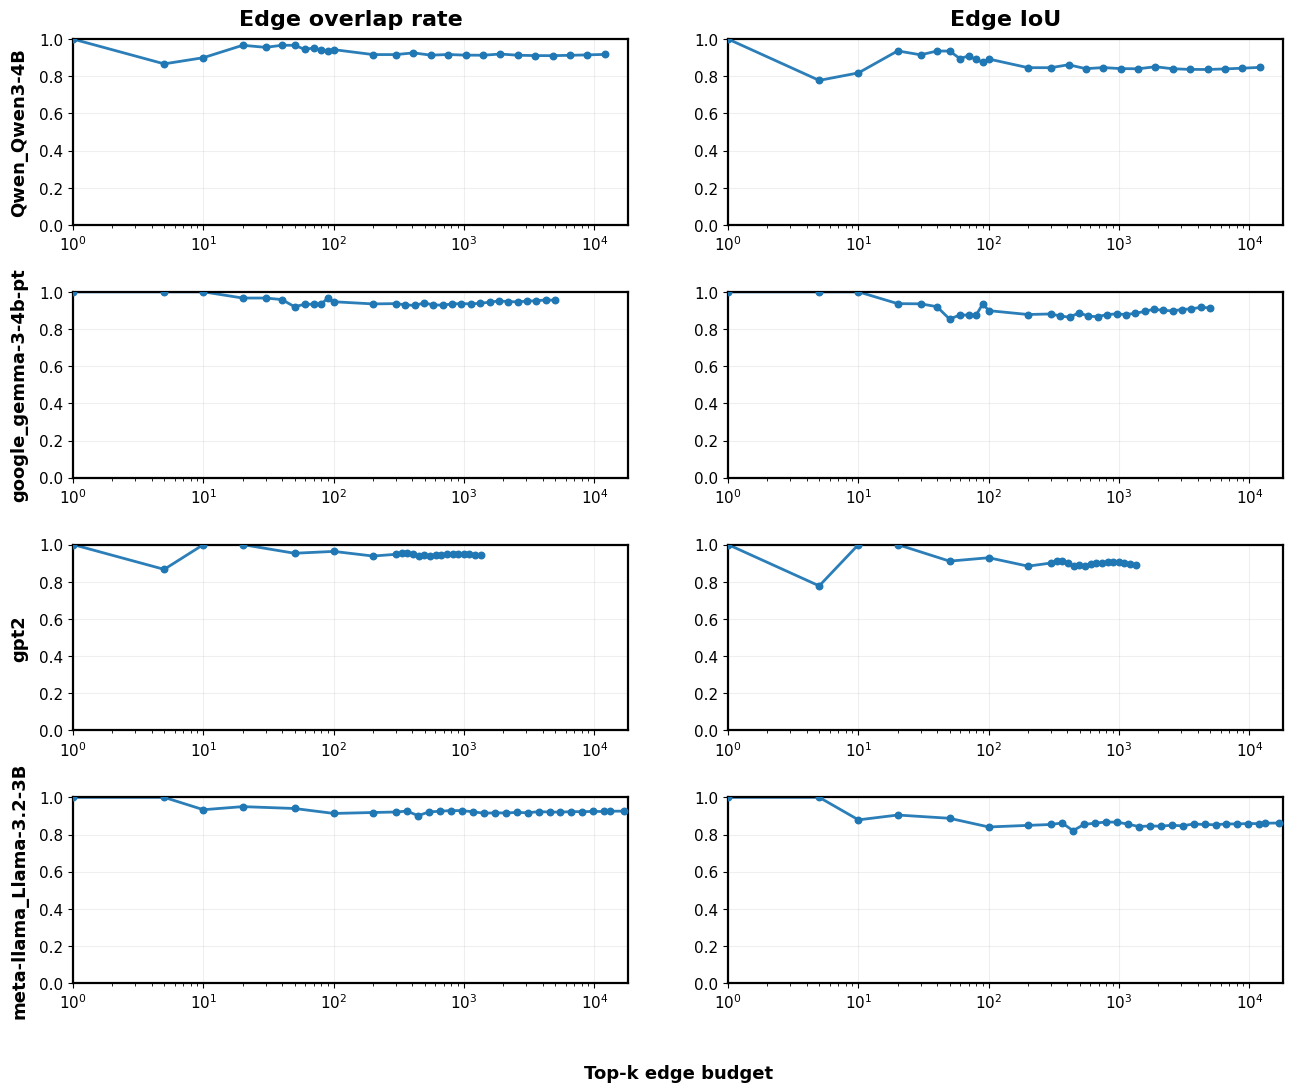

In [51]:
if not edge_stability_df.empty:
    import matplotlib.pyplot as plt

    edge_preview_cols = ["model_dir", "sample_size", "seed_a", "seed_b", "top_k", "edge_overlap", "edge_overlap_rate", "edge_jaccard"]
    display(edge_stability_df[[col for col in edge_preview_cols if col in edge_stability_df.columns]].sort_values(["model_dir", "sample_size", "top_k", "seed_a", "seed_b"]))

    edge_metric_specs = [
        ("edge_overlap_rate", "Edge overlap rate"),
        ("edge_jaccard", "Edge IoU"),
    ]
    edge_metric_specs = [spec for spec in edge_metric_specs if spec[0] in edge_stability_df.columns]

    if not edge_metric_specs:
        display(Markdown("No edge-stability metrics available to plot."))
    else:
        edge_curve = (
            edge_stability_df.groupby(["model_dir", "sample_size", "top_k"], as_index=False, observed=False)[[metric for metric, _ in edge_metric_specs]]
            .mean()
        )
        edge_curve = apply_model_order(edge_curve, MODEL_ORDER)

        def clean_edge_model_label(model_dir):
            label = str(model_dir)
            return label.split("/")[-1] if "/" in label else label

        sample_sizes = sorted(edge_curve["sample_size"].dropna().unique().tolist())
        sample_colors = {
            sample_size: plt.cm.tab10(index % 10)
            for index, sample_size in enumerate(sample_sizes)
        }

        title_size = 16
        label_size = 13
        tick_size = 11
        fig, axes = plt.subplots(
            len(MODEL_ORDER),
            len(edge_metric_specs),
            figsize=(7.2 * len(edge_metric_specs), 2.9 * len(MODEL_ORDER)),
            squeeze=False,
        )
        plotted_topk = []

        for row_index, model_dir in enumerate(MODEL_ORDER):
            model_frame = edge_curve.loc[edge_curve["model_dir"].astype(str) == str(model_dir)].copy()
            for col_index, (metric, metric_title) in enumerate(edge_metric_specs):
                ax = axes[row_index, col_index]
                panel_has_data = False
                for sample_size in sample_sizes:
                    sub = model_frame.loc[model_frame["sample_size"] == sample_size].sort_values("top_k")
                    sub = sub.dropna(subset=["top_k", metric])
                    if sub.empty:
                        continue
                    panel_has_data = True
                    plotted_topk.extend(sub.loc[sub["top_k"] > 0, "top_k"].tolist())
                    ax.plot(
                        sub["top_k"],
                        sub[metric],
                        color=sample_colors[sample_size],
                        linewidth=2.0,
                        alpha=0.95,
                        zorder=2,
                    )
                    ax.scatter(
                        sub["top_k"],
                        sub[metric],
                        color=sample_colors[sample_size],
                        s=22,
                        zorder=3,
                    )
                if row_index == 0:
                    ax.set_title(metric_title, fontsize=title_size, fontweight="bold", pad=10)
                if col_index == 0:
                    ax.set_ylabel(clean_edge_model_label(model_dir), fontsize=label_size, fontweight="bold", labelpad=8)
                ax.set_ylim(0.0, 1.0)
                ax.grid(alpha=0.2)
                ax.tick_params(axis="both", labelsize=tick_size)
                for spine in ax.spines.values():
                    spine.set_linewidth(1.6)
                if not panel_has_data:
                    ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", color="#666666", fontsize=tick_size)

        if plotted_topk:
            min_topk = float(min(plotted_topk))
            max_topk = float(max(plotted_topk))
            axis_right = max_topk * 1.08 if max_topk > 0 else 1.0
            for ax in axes.flat:
                ax.set_xscale("log")
                ax.set_xlim(min_topk, axis_right)

        plt.tight_layout(rect=[0.08, 0.06, 0.985, 0.95])
        fig.subplots_adjust(hspace=0.36, wspace=0.18)

        grid_left = min(ax.get_position().x0 for ax in axes.flat)
        grid_right = max(ax.get_position().x1 for ax in axes.flat)
        grid_center = (grid_left + grid_right) / 2.0
        fig.text(grid_center, 0.02, "Top-k edge budget", ha="center", va="center", fontsize=label_size, fontweight="bold")
        plt.show()


## Readout Checklist

- Localized: steep keep-only recovery, steep ablation damage, high top-k attribution mass, high Gini, low effective edge count, stable top edges across seeds.
- Distributed: gradual keep-only recovery, gradual ablation damage, flatter cumulative mass, higher effective edge count, possibly stable layers/nodes but less stable exact edges.
- Noisy estimate: low held-out faithfulness and low overlap at small samples, improving with sample size.

## Shadow Rediscovery After Necessary-Circuit Ablation

This section loads saved `eap-shadow-rediscovery` outputs and asks whether a second compact circuit can be rediscovered after removing part of the source circuit.

- `remove_top_<k>_edges`: remove the top `k` collapsed edges from the source ranking.
- `remove_first_85pct_circuit`: remove the smallest source budget whose held-out faithfulness first reached `0.85`.

If rediscovery stays near zero and the removed edges do not reappear, that argues against a strong disjoint shadow circuit.

In [45]:
SHADOW_RESULTS_ROOT = PROJECT_ROOT / "results" / "eap_ig"
SHADOW_DAY = None


def discover_shadow_rediscovery_runs(model_order, expected_dataset_sets=None, day=None):
    rows = []
    expected_dataset_sets = expected_dataset_sets or {}
    for model_dir in model_order:
        model_root = SHADOW_RESULTS_ROOT / model_dir
        if not model_root.exists():
            continue
        for dataset_dir in sorted(path for path in model_root.iterdir() if path.is_dir()):
            for day_dir in sorted(path for path in dataset_dir.iterdir() if path.is_dir() and path.name.startswith("shadow_rediscovery_")):
                shadow_dir = day_dir / "shadow_rediscovery"
                summary_paths = sorted(
                    shadow_dir.glob("shadow_rediscovery_summary_*.json"),
                    key=lambda path: path.stat().st_mtime,
                )
                if not summary_paths:
                    continue
                summary_path = summary_paths[-1]
                rows.append({
                    "model_dir": model_dir,
                    "dataset_set": dataset_dir.name,
                    "shadow_day": day_dir.name,
                    "summary_path": summary_path,
                    "modified": summary_path.stat().st_mtime,
                })
    if not rows:
        return pd.DataFrame()
    all_runs = pd.DataFrame(rows).sort_values(["model_dir", "modified"], ascending=[True, False]).reset_index(drop=True)
    if day is not None:
        all_runs = all_runs[all_runs["shadow_day"] == day].copy()
    selected_rows = []
    for model_dir in model_order:
        group = all_runs[all_runs["model_dir"] == model_dir].copy()
        if group.empty:
            continue
        expected_dataset_set = expected_dataset_sets.get(model_dir)
        if expected_dataset_set is not None:
            matched = group[group["dataset_set"] == expected_dataset_set].copy()
            if not matched.empty:
                group = matched
        selected_rows.append(group.iloc[0].to_dict())
    if not selected_rows:
        return pd.DataFrame()
    return apply_model_order(pd.DataFrame(selected_rows), model_order)


def load_shadow_rediscovery_frames(shadow_runs):
    summary_rows = []
    sweep_frames = []
    for _, run in shadow_runs.iterrows():
        summary = json.loads(Path(run["summary_path"]).read_text())
        for variant, artifact in summary.get("artifacts", {}).items():
            graph_summary = artifact.get("graph_summary", {})
            overlap = graph_summary.get("overlap", {})
            source = artifact.get("source", {})
            threshold_row = source.get("first_threshold_row", {})
            budget_sweep = read_csv_if_exists(artifact.get("paths", {}).get("budget_sweep"))
            best_row = {}
            if not budget_sweep.empty:
                budget_sweep = budget_sweep.copy()
                budget_sweep["model_dir"] = run["model_dir"]
                budget_sweep["dataset_set"] = run["dataset_set"]
                budget_sweep["shadow_day"] = run["shadow_day"]
                budget_sweep["variant"] = variant
                best_row = budget_sweep.sort_values("faithfulness_mean", ascending=False).iloc[0].to_dict()
                sweep_frames.append(budget_sweep)
            summary_rows.append({
                "model_dir": run["model_dir"],
                "dataset_set": run["dataset_set"],
                "shadow_day": run["shadow_day"],
                "variant": variant,
                "removed_collapsed_edge_count": graph_summary.get("removed_collapsed_edge_count"),
                "removed_underlying_edge_count": graph_summary.get("removed_underlying_edge_count"),
                "rediscovered_ranked_edge_count": overlap.get("rediscovered_ranked_edge_count"),
                "removed_edges_rediscovered_count": overlap.get("removed_edges_rediscovered_count"),
                "top_100_source_overlap_count": overlap.get("top_100_source_overlap_count"),
                "top_500_source_overlap_count": overlap.get("top_500_source_overlap_count"),
                "top_1000_source_overlap_count": overlap.get("top_1000_source_overlap_count"),
                "top_100_source_jaccard": overlap.get("top_100_source_jaccard"),
                "top_500_source_jaccard": overlap.get("top_500_source_jaccard"),
                "top_1000_source_jaccard": overlap.get("top_1000_source_jaccard"),
                "source_threshold_budget": threshold_row.get("collapsed_edge_budget"),
                "source_threshold_faithfulness": threshold_row.get("faithfulness_mean"),
                "best_rediscovered_budget": best_row.get("collapsed_edge_budget"),
                "best_rediscovered_faithfulness": best_row.get("faithfulness_mean"),
                "best_rediscovered_accuracy": best_row.get("accuracy_mean"),
            })
    summary_df = apply_model_order(pd.DataFrame(summary_rows), MODEL_ORDER) if summary_rows else pd.DataFrame()
    sweep_df = apply_model_order(pd.concat(sweep_frames, ignore_index=True), MODEL_ORDER) if sweep_frames else pd.DataFrame()
    return summary_df, sweep_df


expected_shadow_dataset_sets = {}
for model_dir in MODEL_ORDER:
    manifest = MANIFEST_BY_MODEL.get(model_dir, {})
    dataset_set = manifest.get("config", {}).get("dataset_set_name") or manifest.get("dataset_summary", {}).get("dataset_set_name")
    if dataset_set is not None:
        expected_shadow_dataset_sets[model_dir] = dataset_set

shadow_runs = discover_shadow_rediscovery_runs(MODEL_ORDER, expected_dataset_sets=expected_shadow_dataset_sets, day=SHADOW_DAY)
display(Markdown("### Shadow rediscovery runs"))
if shadow_runs.empty:
    display(Markdown("No saved `eap-shadow-rediscovery` runs matched the selected models."))
else:
    display(shadow_runs[["model_dir", "dataset_set", "shadow_day", "summary_path"]])
    shadow_summary_df, shadow_sweep_df = load_shadow_rediscovery_frames(shadow_runs)
    if not shadow_summary_df.empty:
        shadow_display = shadow_summary_df.copy()
        for col in [
            "top_100_source_jaccard",
            "top_500_source_jaccard",
            "top_1000_source_jaccard",
            "source_threshold_faithfulness",
            "best_rediscovered_faithfulness",
            "best_rediscovered_accuracy",
        ]:
            if col in shadow_display.columns:
                shadow_display[col] = shadow_display[col].astype(float).round(6)
        display(Markdown("### Shadow rediscovery summary"))
        display(shadow_display.sort_values(["model_dir", "variant"]).reset_index(drop=True))


### Shadow rediscovery runs

,model_dir,dataset_set,shadow_day,summary_path
0,Qwen_Qwen3-4B,model_specific_correct,shadow_rediscovery_2026-06-12,/gpfs/home4/spunzo/grammatical-circuits/animac...
1,google_gemma-3-4b-pt,model_specific_correct,shadow_rediscovery_2026-06-12,/gpfs/home4/spunzo/grammatical-circuits/animac...
2,gpt2,model_specific_correct,shadow_rediscovery_top20_fullbudget_2026-06-27,/gpfs/home4/spunzo/grammatical-circuits/animac...
3,meta-llama_Llama-3.2-3B,model_specific_correct,shadow_rediscovery_2026-06-12,/gpfs/home4/spunzo/grammatical-circuits/animac...


### Shadow rediscovery summary

,model_dir,dataset_set,shadow_day,variant,removed_collapsed_edge_count,removed_underlying_edge_count,rediscovered_ranked_edge_count,removed_edges_rediscovered_count,top_100_source_overlap_count,top_500_source_overlap_count,top_1000_source_overlap_count,top_100_source_jaccard,top_500_source_jaccard,top_1000_source_jaccard,source_threshold_budget,source_threshold_faithfulness,best_rediscovered_budget,best_rediscovered_faithfulness,best_rediscovered_accuracy
0,Qwen_Qwen3-4B,model_specific_correct,shadow_rediscovery_2026-06-12,remove_first_85pct_circuit,12017,28099,677582,0,0,0,0,0.000000,0.000000,0.000000,12017,0.855521,16149,0.000029,0.000000
1,Qwen_Qwen3-4B,model_specific_correct,shadow_rediscovery_2026-06-12,remove_top_100_edges,100,144,689499,0,0,400,900,0.000000,0.666667,0.818182,12017,0.855521,16343,0.007873,0.010263
2,google_gemma-3-4b-pt,model_specific_correct,shadow_rediscovery_2026-06-12,remove_first_85pct_circuit,4992,12570,41334,0,0,0,0,0.000000,0.000000,0.000000,4992,0.879058,5288,0.000066,0.000000
3,google_gemma-3-4b-pt,model_specific_correct,shadow_rediscovery_2026-06-12,remove_top_100_edges,100,174,46226,0,0,400,900,0.000000,0.666667,0.818182,4992,0.879058,4983,0.015553,0.030741
4,gpt2,model_specific_correct,shadow_rediscovery_top20_fullbudget_2026-06-27,remove_top_20_edges,20,32,11591,0,80,480,980,0.666667,0.923077,0.960784,1342,0.862067,1153,0.023524,0.019900
5,meta-llama_Llama-3.2-3B,model_specific_correct,shadow_rediscovery_2026-06-12,remove_first_85pct_circuit,16806,42230,221517,0,0,0,0,0.000000,0.000000,0.000000,16806,0.920909,33228,0.000183,0.001181
6,meta-llama_Llama-3.2-3B,model_specific_correct,shadow_rediscovery_2026-06-12,remove_top_100_edges,100,152,238223,0,0,400,900,0.000000,0.666667,0.818182,16806,0.920909,2888,0.004544,0.012754


In [46]:
if shadow_runs.empty:
    display(Markdown("No shadow-rediscovery curves to plot."))
elif shadow_sweep_df.empty:
    display(Markdown("Saved shadow-rediscovery runs did not include budget-sweep CSVs."))
else:
    def shadow_variant_label(variant_name):
        match = re.fullmatch(r"remove_top_(\\d+)_edges", str(variant_name))
        if match is not None:
            count = int(match.group(1))
            suffix = "edge" if count == 1 else "edges"
            return f"Remove top {count} {suffix}"
        if variant_name == "remove_first_85pct_circuit":
            return "Remove 85% circuit"
        return variant_name
    shadow_plot_df = shadow_sweep_df.copy()
    shadow_plot_df["variant_label"] = shadow_plot_df["variant"].map(shadow_variant_label)
    shadow_plot_df = ensure_model_panels(
        shadow_plot_df,
        MODEL_ORDER,
        {
            "collapsed_edge_budget": np.nan,
            "faithfulness_mean": np.nan,
            "variant_label": "__missing__",
        },
    )
    fig = px.line(
        shadow_plot_df,
        x="collapsed_edge_budget",
        y="faithfulness_mean",
        color="variant_label",
        facet_col="model_dir",
        facet_col_wrap=MODEL_FACET_WRAP,
        markers=True,
        log_x=True,
        category_orders={"model_dir": MODEL_ORDER},
        title="Shadow rediscovery: held-out faithfulness after removing source-circuit edges",
        labels={
            "collapsed_edge_budget": "Rediscovered collapsed-edge budget",
            "faithfulness_mean": "Rediscovered faithfulness mean",
            "variant_label": "Removed source circuit",
        },
    )
    finalize_model_facets(fig, shadow_plot_df, MODEL_ORDER, "No shadow-rediscovery run", height=760).show()

    overlap_cols = [
        "model_dir",
        "variant",
        "removed_collapsed_edge_count",
        "removed_edges_rediscovered_count",
        "top_100_source_overlap_count",
        "top_500_source_overlap_count",
        "top_1000_source_overlap_count",
        "best_rediscovered_budget",
        "best_rediscovered_faithfulness",
    ]
    display(Markdown("### Rediscovery overlap checklist"))
    display(shadow_summary_df[[col for col in overlap_cols if col in shadow_summary_df.columns]].sort_values(["model_dir", "variant"]).reset_index(drop=True))


### Rediscovery overlap checklist

,model_dir,variant,removed_collapsed_edge_count,removed_edges_rediscovered_count,top_100_source_overlap_count,top_500_source_overlap_count,top_1000_source_overlap_count,best_rediscovered_budget,best_rediscovered_faithfulness
0,Qwen_Qwen3-4B,remove_first_85pct_circuit,12017,0,0,0,0,16149,0.000029
1,Qwen_Qwen3-4B,remove_top_100_edges,100,0,0,400,900,16343,0.007873
2,google_gemma-3-4b-pt,remove_first_85pct_circuit,4992,0,0,0,0,5288,0.000066
3,google_gemma-3-4b-pt,remove_top_100_edges,100,0,0,400,900,4983,0.015553
4,gpt2,remove_top_20_edges,20,0,80,480,980,1153,0.023524
5,meta-llama_Llama-3.2-3B,remove_first_85pct_circuit,16806,0,0,0,0,33228,0.000183
6,meta-llama_Llama-3.2-3B,remove_top_100_edges,100,0,0,400,900,2888,0.004544


## Static Top-k Keep/Ablate Grid

Static Matplotlib summary of the ranked top-k curves. Each row is a model, each column is a metric, and each panel overlays keep-only and ablate-only curves.


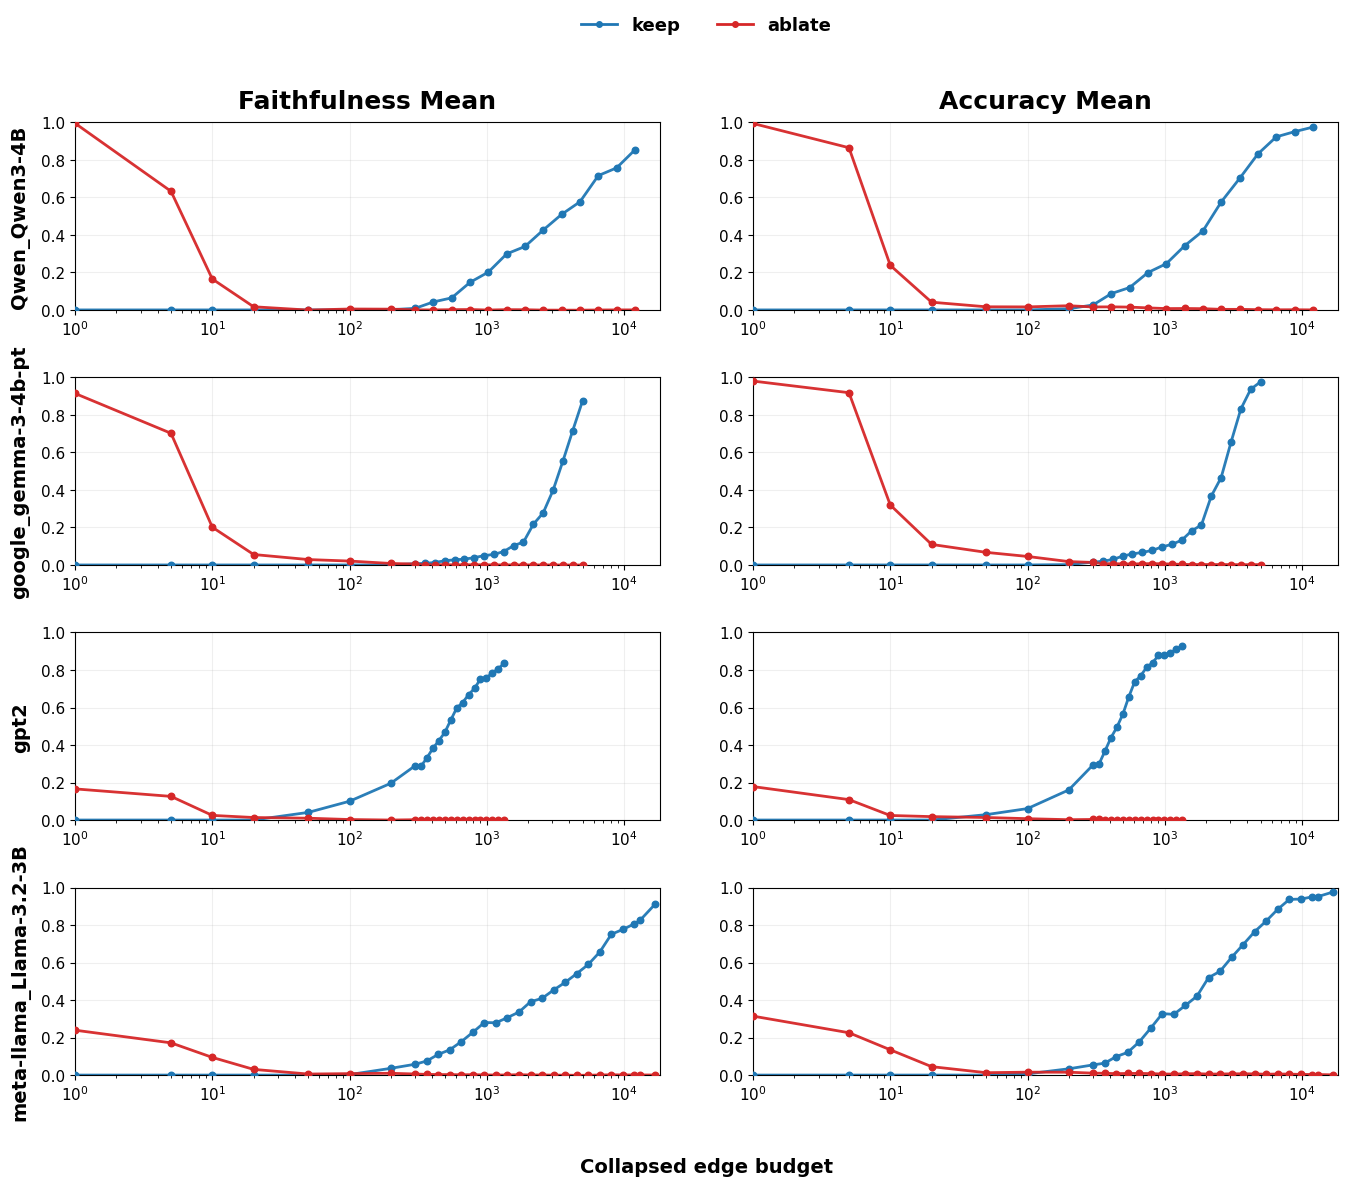

In [47]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

static_metric_cols = ["faithfulness_mean", "accuracy_mean"]
static_metric_titles = {
    "faithfulness_mean": "Faithfulness Mean",
    "accuracy_mean": "Accuracy Mean",
}
static_mode_styles = {
    "keep_top": {"label": "keep", "color": "#1f77b4", "linestyle": "-", "marker": "o"},
    "ablate_top": {"label": "ablate", "color": "#d62728", "linestyle": "-", "marker": "o"},
}


def clean_static_model_label(model_dir):
    label = str(model_dir)
    return label.split("/")[-1] if "/" in label else label


static_eval_df = eval_df[eval_df["mode"].isin(static_mode_styles)].copy() if not eval_df.empty else pd.DataFrame()
if static_eval_df.empty:
    display(Markdown("No ranked keep/ablate top-k evaluation data available for the static summary plot."))
else:
    for column in ["collapsed_edge_budget", *static_metric_cols]:
        if column in static_eval_df.columns:
            static_eval_df[column] = pd.to_numeric(static_eval_df[column], errors="coerce")

    static_curve = (
        static_eval_df.groupby(["model_dir", "collapsed_edge_budget", "mode"], as_index=False, observed=False)[static_metric_cols]
        .mean()
    )
    static_curve = apply_model_order(static_curve, MODEL_ORDER)

    title_size = 18
    label_size = 14
    tick_size = 11
    legend_size = 13
    fig, axes = plt.subplots(len(MODEL_ORDER), len(static_metric_cols), figsize=(15, 3.0 * len(MODEL_ORDER)), squeeze=False)
    plotted_budgets = []

    for row_index, model_dir in enumerate(MODEL_ORDER):
        model_frame = static_curve.loc[static_curve["model_dir"].astype(str) == str(model_dir)].copy()
        for col_index, metric in enumerate(static_metric_cols):
            ax = axes[row_index, col_index]
            panel_has_data = False
            for mode, style in static_mode_styles.items():
                sub = model_frame.loc[model_frame["mode"] == mode].sort_values("collapsed_edge_budget")
                sub = sub.dropna(subset=["collapsed_edge_budget", metric])
                if sub.empty:
                    continue
                panel_has_data = True
                plotted_budgets.extend(sub.loc[sub["collapsed_edge_budget"] > 0, "collapsed_edge_budget"].tolist())
                ax.plot(
                    sub["collapsed_edge_budget"],
                    sub[metric],
                    color=style["color"],
                    linestyle=style["linestyle"],
                    linewidth=2.0,
                    alpha=0.95,
                    label=style["label"],
                    zorder=2,
                )
                ax.scatter(
                    sub["collapsed_edge_budget"],
                    sub[metric],
                    color=style["color"],
                    marker=style["marker"],
                    s=22,
                    zorder=3,
                )
            if row_index == 0:
                ax.set_title(static_metric_titles[metric], fontsize=title_size, fontweight="bold", pad=10)
            if col_index == 0:
                ax.set_ylabel(clean_static_model_label(model_dir), fontsize=label_size, fontweight="bold", labelpad=8)
            ax.set_ylim(0.0, 1.0)
            ax.grid(alpha=0.2)
            ax.tick_params(axis="both", labelsize=tick_size)
            if not panel_has_data:
                ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center", color="#666666", fontsize=tick_size)

    if plotted_budgets:
        min_budget = float(min(plotted_budgets))
        max_budget = float(max(plotted_budgets))
        axis_right = max_budget * 1.08 if max_budget > 0 else 1.0
        for ax in axes.flat:
            ax.set_xscale("log")
            ax.set_xlim(min_budget, axis_right)

    handles = [
        Line2D(
            [0],
            [0],
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=4,
            linewidth=2.0,
            label=style["label"],
        )
        for style in static_mode_styles.values()
    ]
    plt.tight_layout(rect=[0.08, 0.06, 0.985, 0.93])
    fig.subplots_adjust(hspace=0.36, wspace=0.16)

    grid_left = min(ax.get_position().x0 for ax in axes.flat)
    grid_right = max(ax.get_position().x1 for ax in axes.flat)
    grid_center = (grid_left + grid_right) / 2.0
    fig.legend(
        handles,
        [handle.get_label() for handle in handles],
        loc="upper center",
        bbox_to_anchor=(grid_center, 0.992),
        ncol=2,
        frameon=False,
        prop={"size": legend_size, "weight": "bold"},
    )
    fig.text(grid_center, 0.02, "Collapsed edge budget", ha="center", va="center", fontsize=label_size, fontweight="bold")
    plt.show()
